# Fundamentals of Machine Learning — Exercise 3
## K-means, Distance, Scaling, and Cluster Interpretation

In this exercise, you will move from exploratory analysis to **unsupervised learning**.

The main question is not only:

> *How do I run K-means?*

but especially:

> *What representation, distance, number of clusters, and interpretation make the result meaningful?*

We will use the same classroom workflow as in Exercises 1 and 2:

> **question → prediction → computation → visualisation → interpretation → verification**

### Learning outcomes

After completing this exercise, you should be able to:

- explain why distance is central to K-means,
- recognise when feature scales distort a distance,
- describe the role of centroids and cluster assignments,
- use inertia and the silhouette score as evidence when selecting \(k\),
- distinguish a cluster label from a real-world meaning,
- interpret clusters using the original variables,
- check whether a clustering result is reasonably stable,
- use an AI chatbot as a tutor that questions your interpretation rather than writing it for you.

## How to work in this exercise

Most code is already prepared. Your task is to:

1. **predict** what you expect before running a cell,
2. **change** only a small number of clearly marked settings,
3. **compare** alternative results,
4. **interpret** clusters using numerical evidence,
5. **verify** important claims using a second output.

A clustering algorithm always returns a result. That does **not** guarantee that the result is useful, stable, or meaningful.

## 0. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 1. Distance is the engine of K-means

A data point is represented by a vector of feature values. K-means repeatedly assigns each point to the nearest centroid.

Consider three simplified passengers described only by age and fare:

| Passenger | Age | Fare |
|---|---:|---:|
| A | 20 | 10 |
| B | 40 | 11 |
| C | 21 | 100 |

### Predict before running

1. Which passenger is closer to A: B or C?
2. Which feature do you expect to dominate the raw Euclidean distance?
3. Is the numerically nearest passenger necessarily the most similar in a real-world sense?

### Euclidean distance

The **Euclidean distance** between two points (vectors) $\mathbf{x}$ and $\mathbf{y}$ is defined as:

$$
d(\mathbf{x}, \mathbf{y}) =
\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

where:
- $x_i$ is the value of the $i$-th feature of $\mathbf{x}$,
- $y_i$ is the value of the $i$-th feature of $\mathbf{y}$,
- $n$ is the number of features.

In [ ]:
# Complete the code
def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    # Compute the Euclidean distance between two numpy arrays
    """
    Use functions np.sqrt and sum
    """
    return 

In [3]:
passengers_small = pd.DataFrame(
    {
        "Age": [20, 40, 21],
        "Fare": [10, 11, 100],
    },
    index=["A", "B", "C"],
)

raw_distances = pd.DataFrame(
    pairwise_distances(passengers_small, metric=euclidean_distance),
    index=passengers_small.index,
    columns=passengers_small.index,
)

passengers_small, raw_distances

(   Age  Fare
 A   20    10
 B   40    11
 C   21   100,
        A      B      C
 A  0.000 20.025 90.006
 B 20.025  0.000 91.005
 C 90.006 91.005  0.000)

### Stop and explain

Complete the sentences:

- In the raw representation, A is closer to ...
- The distance is strongly influenced by ...
- This result does / does not match my intuitive definition of passenger similarity because ...

### Change the representation

The two features use different units and scales. Before calculating distances, we can transform each feature using **standardisation**.

For each value $x$, we calculate its **z-score**:

$$
z = \frac{x - \mu}{\sigma}
$$

where:

- $x$ is the original value,
- $\mu$ is the mean of the feature,
- $\sigma$ is the standard deviation of the feature.

After standardisation, each feature is centered around **0** and has a standard deviation of **1**.

**Question:** How could this transformation affect the Euclidean distances between passengers?

In [ ]:
#Complete the code
def standard_scaler(data: pd.DataFrame) -> pd.DataFrame:
    means =   # Use mean function
    stds =  # Use std function with ddof=0
    
    return (data - means) / stds

# Tests:
passengers_small_scaled = standard_scaler(passengers_small)

assert np.allclose(passengers_small_scaled.mean(), 0)
assert np.allclose(passengers_small_scaled.std(ddof=0), 1)

In [ ]:
small_scaler = StandardScaler()
passengers_small_scaled = pd.DataFrame(
    small_scaler.fit_transform(passengers_small),
    index=passengers_small.index,
    columns=passengers_small.columns,
)

scaled_distances = pd.DataFrame(
    pairwise_distances(passengers_small_scaled, metric="euclidean"), # Note that we use standard implementation of Euclidean distance from sklearn
    index=passengers_small.index,
    columns=passengers_small.index,
)

print("Standardised values")
display(passengers_small_scaled)

print("Distances after standardisation")
display(scaled_distances)

Standardised values


,Age,Fare
A,-0.761,-0.719
B,1.413,-0.695
C,-0.652,1.414


Distances after standardisation


,A,B,C
A,0.000,2.174,2.136
B,2.174,0.000,2.952
C,2.136,2.952,0.000


### Verification checkpoint

1. Did the nearest neighbour change?
2. Which answer is “correct”?
3. Standardisation gives Age and Fare comparable scales. Does this mean they should also have equal importance when measuring passenger similarity? What information would you need to decide?

The important conclusion is not that scaling is always correct.

## Reading: Other scaling methods

`StandardScaler` is a common choice, but it is **not always the best transformation**. Different scalers preserve or modify different properties of the original distribution.

### Min-Max scaling

`MinMaxScaler` transforms each feature into a predefined range, usually $[0,1]$:

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

**Use it when:**
- you need values in a fixed range such as $[0,1]$,
- preserving the relative position of values within the original range is important,
- the data do not contain strong outliers.

**Be careful:** the minimum and maximum are strongly affected by outliers. A single extreme value can compress most observations into a very small part of the resulting range.


### Robust scaling

`RobustScaler` uses the **median** and **interquartile range (IQR)** instead of the mean and standard deviation:

$$
x' = \frac{x - \operatorname{median}(x)}{Q_3 - Q_1}
$$

**Use it when:**
- the feature contains outliers,
- you want scaling to be less influenced by extreme observations.

Unlike `StandardScaler`, extreme values have much less influence on the parameters used for scaling.


### Max-Absolute scaling

`MaxAbsScaler` divides values by the largest absolute value of the feature:

$$
x' = \frac{x}{\max |x|}
$$

The transformed values are approximately in the range $[-1,1]$.

**Use it when:**
- the data are already centered around zero,
- you work with sparse data and want to preserve zero values.

It does **not center the data**, which makes it particularly useful for sparse matrices.


### Normalization

`Normalizer` is different from the previous methods. Instead of scaling each **feature (column)** independently, it scales each **sample (row)** to have unit norm.

For L2 normalization:

$$
\mathbf{x}' = \frac{\mathbf{x}}{\|\mathbf{x}\|_2}
$$

**Use it when:**
- the direction of a vector is more important than its magnitude,
- individual rows represent vectors, for example document vectors in text processing.

`Normalizer` should therefore not be considered a direct replacement for `StandardScaler`: it transforms **rows**, while the previous scalers transform **features**.

### Power transformation

`PowerTransformer` goes one step further than ordinary scaling. It does not only change the scale of a feature - it also changes the **shape of its distribution**.

It applies a nonlinear transformation designed to make the data more **Gaussian-like** and to reduce **skewness**.

Scikit-learn supports two transformations:

- **Yeo-Johnson** - works with positive, zero, and negative values,
- **Box-Cox** - can only be applied to strictly positive values.

By default, `PowerTransformer` also standardises the transformed data to have approximately zero mean and unit variance.

**Use it when:**
- a feature is strongly skewed,
- extreme values create a long tail in the distribution,
- reducing skewness may make the feature easier to model.

**Be careful:** unlike `StandardScaler`, `MinMaxScaler`, or `RobustScaler`, a power transformation changes the **relative distances between values** because it is nonlinear.

For example, a strongly right-skewed feature:

`1, 2, 3, 5, 10, 50, 200`

can be transformed so that the large values are compressed and the resulting distribution is more symmetric.

**Scaling vs. transformation:**  
`StandardScaler`, `MinMaxScaler`, and `RobustScaler` mainly change the **location and scale** of the data. `PowerTransformer` can additionally change the **shape of the distribution**.


### Which one should I choose?

There is no universally best scaler.

| Method | Typical reason to use it |
|---|---|
| `StandardScaler` | General-purpose scaling; features have different scales |
| `MinMaxScaler` | A fixed range such as $[0,1]$ is desirable |
| `RobustScaler` | Data contain significant outliers |
| `MaxAbsScaler` | Sparse data or preserving zeros is important |
| `Normalizer` | Relative proportions/direction within each sample matter |
| `PowerTransformer` | A feature is strongly skewed and its distribution should be transformed |

**Remember:** scaling changes the representation of the data. For methods based on distances, such as k-NN or k-means, changing the representation can directly change which observations are considered similar.

**Question:** Suppose `Fare` contains a few extremely expensive tickets. Which scaler would you consider instead of `StandardScaler`, and why?

## 2. What K-means does

We first use artificial 2D data because the result can be inspected directly.

K-means alternates between two operations:

1. assign every point to the nearest centroid,
2. move each centroid to the mean of its assigned points.

It stops when the assignments or centroids no longer change substantially.

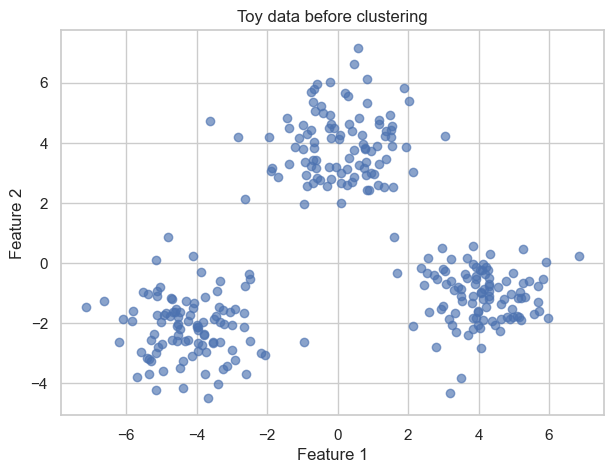

In [6]:
X_toy, true_group = make_blobs(
    n_samples=300,
    centers=[(-4, -2), (0, 4), (4, -1)],
    cluster_std=[1.0, 1.2, 0.9],
    random_state=12,
)

plt.figure(figsize=(7, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], alpha=0.65)
plt.title("Toy data before clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Question

1. How many compact groups do you see?

## Reading: K-means clustering

**K-means** is an unsupervised learning algorithm used to divide observations into $k$ groups called **clusters**.

The basic idea is simple:

> Observations that are close to each other should belong to the same cluster.

The algorithm represents each cluster by a point called its **centroid**.

### Centroid

A **centroid** is the center of a cluster. It is calculated as the mean of all observations currently assigned to that cluster.

For a cluster $C_j$ containing $n_j$ observations, its centroid is:

$$
\boldsymbol{\mu}_j =
\frac{1}{n_j}
\sum_{\mathbf{x} \in C_j} \mathbf{x}
$$

The centroid does not have to correspond to an actual observation in the dataset. It is an artificial point representing the average position of the observations in the cluster.


### How does K-means work?

Suppose we want to divide the data into $k$ clusters.

**1. Initialize the centroids**

Choose $k$ initial centroid positions.

**2. Assignment step**

For every observation, calculate its distance to each centroid and assign it to the nearest one:

$$
c_i =
\underset{j}{\operatorname{argmin}}
\; d(\mathbf{x}_i,\boldsymbol{\mu}_j)
$$

where $c_i$ identifies the cluster assigned to observation $\mathbf{x}_i$.

Euclidean distance is commonly used as the distance measure.

**3. Update step**

Recalculate each centroid as the mean of all observations assigned to its cluster:

$$
\boldsymbol{\mu}_j =
\frac{1}{|C_j|}
\sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i
$$

**4. Repeat**

Repeat the **assignment** and **update** steps until the cluster assignments no longer change significantly or the centroids stop moving.


### What is K-means trying to minimize?

K-means tries to create compact clusters by minimizing the squared distances between observations and their assigned centroids:

$$
J =
\sum_{j=1}^{k}
\sum_{\mathbf{x}_i \in C_j}
\|\mathbf{x}_i-\boldsymbol{\mu}_j\|^2
$$

This quantity is often called the **within-cluster sum of squares (WCSS)** or **inertia**.

A smaller value means that observations are, on average, closer to the centers of their clusters.


### Important properties of K-means

- **$k$ must be chosen in advance.**
- A **centroid** is the mean position of a cluster and does not have to be an actual observation.
- Cluster membership depends on **distance**, so feature scaling can strongly affect the result.
- Different initial centroid positions can lead to different final clusters.
- K-means works best when clusters are reasonably **compact and separated**.
- K-means always assigns every observation to one of the $k$ clusters, including possible outliers.

**Connection to the previous section:**  
Because K-means uses distances, features with larger numerical scales can dominate the clustering. This is why scaling the features before applying K-means is often important.

**Question:**

Why can changing the scale of one feature change the resulting clusters?

In [ ]:
def kmeans(
    data: np.ndarray,
    centroids: np.ndarray,
    max_iterations: int = 100
) -> tuple[np.ndarray, np.ndarray]:

    for _ in range(max_iterations):

        # 1. Calculate the distance of each observation
        #    from each centroid
        distances = np.array([
            [
                # TODO:Add euclidean distance calculation implemented before
                
                for centroid in centroids
            ]
            for point in data
        ])

        # 2. TODO: Assign each observation to its nearest centroid use np.argmin
        labels = 

        # 3. Calculate new centroids
        new_centroids = np.array([
            # Select all points assigned to the current cluster and calculate their mean
            # TODO: Use mean function and data[labels == cluster_id]
            
            for cluster_id in range(len(centroids))
        ])

        # 4. Stop if the centroids no longer change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

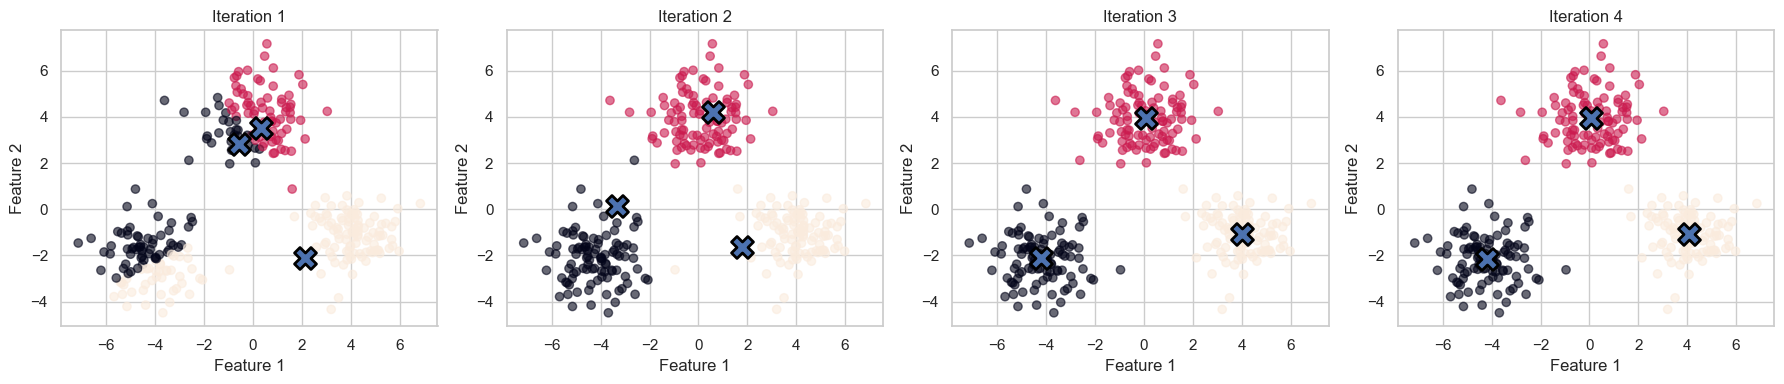

In [12]:
rng = np.random.default_rng(42)

centroid_indices = rng.choice(
    len(X_toy),
    size=3,
    replace=False
)

centroids = X_toy[centroid_indices].copy()

history = []

for i in range(4):
    old_centroids = centroids.copy()
    labels, centroids = kmeans(X_toy, centroids, max_iterations=1)
    history.append((labels.copy(), old_centroids.copy()))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for iteration, (labels, centroids) in enumerate(history):

    ax = axes[iteration]

    ax.scatter(
        X_toy[:, 0],
        X_toy[:, 1],
        c=labels,
        alpha=0.6
    )

    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=250,
        edgecolors="black",
        linewidths=2
    )

    ax.set_title(f"Iteration {iteration + 1}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Predict before fitting

1. How do you one initial centroid for each group?
2. Would a different initialisation necessarily produce different final groups?

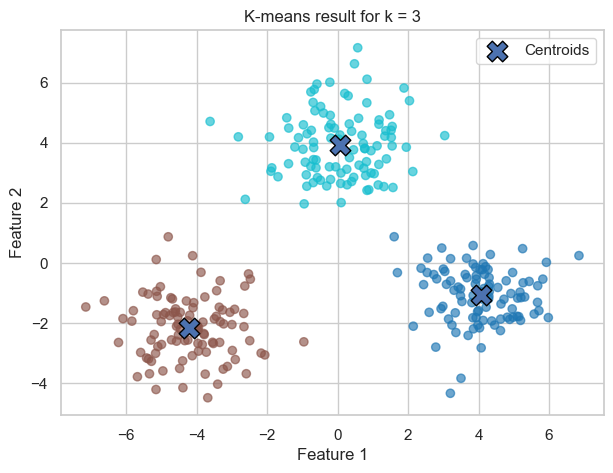

In [7]:
toy_model = KMeans(n_clusters=3, n_init=10, random_state=42)
toy_labels = toy_model.fit_predict(X_toy)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_toy[:, 0],
    X_toy[:, 1],
    c=toy_labels,
    alpha=0.65,
    cmap="tab10",
)
plt.scatter(
    toy_model.cluster_centers_[:, 0],
    toy_model.cluster_centers_[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
    label="Centroids",
)
plt.title("K-means result for k = 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Activity 1 — Read the result

Answer briefly:

1. What does one centroid represent?
2. Why are the cluster identifiers `0`, `1`, and `2` not meaningful names?
3. Does K-means recover the original generator labels exactly?
4. Which visible property of these data makes K-means a reasonable method here?

### Cluster numbers may change without the partition changing

Fit the same model with a different random state. Compare the numeric labels and then compare the partitions using the **Adjusted Rand Index (ARI)**.

ARI compares two assignments while ignoring arbitrary permutations of cluster numbers:

- 1 means identical partitions,
- values near 0 indicate agreement similar to chance,
- negative values indicate worse-than-chance agreement.

In [13]:
toy_model_second = KMeans(n_clusters=3, n_init=10, random_state=7)
toy_labels_second = toy_model_second.fit_predict(X_toy)

comparison_labels = pd.DataFrame(
    {
        "first_run": toy_labels[:20],
        "second_run": toy_labels_second[:20],
    }
)

print("First 20 numeric labels")
display(comparison_labels)

print(
    "ARI between the two partitions:",
    adjusted_rand_score(toy_labels, toy_labels_second),
)

First 20 numeric labels


,first_run,second_run
0,0,2
1,2,0
2,2,0
3,1,1
4,2,0
5,0,2
6,1,1
7,1,1
8,1,1
9,1,1


ARI between the two partitions: 1.0


### Stop and explain

Why can the numeric labels differ even when ARI is close to 1?

## 3. Selecting the number of clusters

K-means requires the number of clusters \(k\) in advance.

We will compare:

- **inertia** - the sum of squared distances from points to their assigned centroid; lower is better, but it always decreases as \(k\) grows,
- **silhouette score** - combines cohesion within clusters and separation from neighbouring clusters; higher is generally better.

Neither measure discovers the one objectively correct answer. They provide evidence that must be combined with visual inspection, stability, and interpretability.

In [14]:
toy_scores = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X_toy)

    toy_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_toy, labels),
        }
    )

toy_scores = pd.DataFrame(toy_scores)
toy_scores

,k,inertia,silhouette
0,2,"2,687.958",0.566
1,3,639.766,0.723
2,4,554.538,0.589
3,5,482.064,0.449
4,6,419.745,0.320
5,7,364.886,0.333
6,8,316.587,0.335


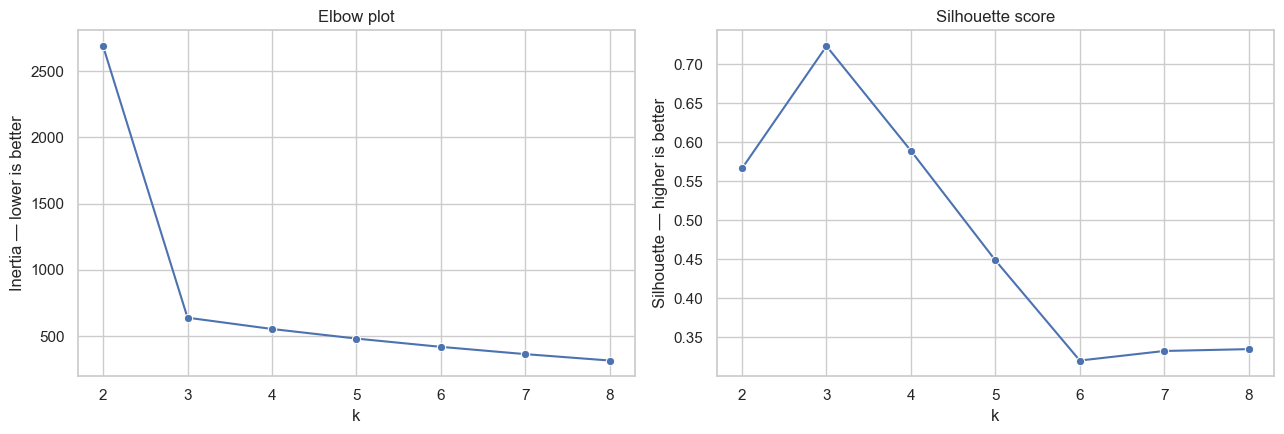

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=toy_scores,
    x="k",
    y="inertia",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Elbow plot")
axes[0].set_ylabel("Inertia - lower is better")

sns.lineplot(
    data=toy_scores,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Silhouette score")
axes[1].set_ylabel("Silhouette - higher is better")

plt.tight_layout()
plt.show()

### Activity 2 - Make and defend a choice

Choose one value of \(k\) and write a short evidence chain:

1. **Candidate:** I would choose \(k = \ldots\)
2. **Inertia evidence:** ...
3. **Silhouette evidence:** ...
4. **Visual evidence:** ...
5. **Limitation:** This choice is not automatically the “true” number of groups because ...

Then change `K_TO_INSPECT` below and inspect the corresponding partition.

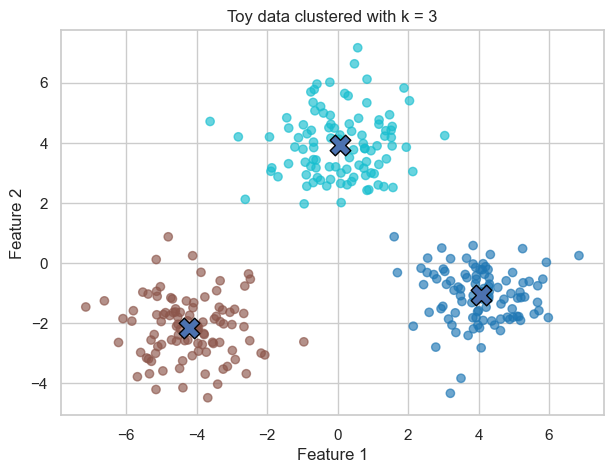

In [18]:
K_TO_INSPECT = 3  # Change this value after making your prediction.

model_to_inspect = KMeans(
    n_clusters=K_TO_INSPECT,
    n_init=10,
    random_state=42,
)
labels_to_inspect = model_to_inspect.fit_predict(X_toy)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_toy[:, 0],
    X_toy[:, 1],
    c=labels_to_inspect,
    alpha=0.65,
    cmap="tab10",
)
plt.scatter(
    model_to_inspect.cluster_centers_[:, 0],
    model_to_inspect.cluster_centers_[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
)
plt.title(f"Toy data clustered with k = {K_TO_INSPECT}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4. Scaling can change the clusters

We now multiply the second feature by 50. The points still describe the same artificial observations, but Euclidean distance will give the second axis much greater numerical influence.

### Predict before running

1. Will the unscaled K-means result remain similar?
2. Will standardisation recover a geometry closer to the original one?
3. Which comparison would be stronger evidence: a visual plot or ARI against the known artificial groups?

In [19]:
X_stretched = X_toy.copy()
X_stretched[:, 1] = X_stretched[:, 1] * 50

labels_stretched_raw = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42,
).fit_predict(X_stretched)

X_stretched_scaled = StandardScaler().fit_transform(X_stretched)

labels_stretched_scaled = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42,
).fit_predict(X_stretched_scaled)

scaling_comparison = pd.Series(
    {
        "ARI: original geometry vs known groups": adjusted_rand_score(
            true_group, toy_labels
        ),
        "ARI: stretched and not scaled": adjusted_rand_score(
            true_group, labels_stretched_raw
        ),
        "ARI: stretched and standardised": adjusted_rand_score(
            true_group, labels_stretched_scaled
        ),
    }
)

scaling_comparison

ARI: original geometry vs known groups   0.990
ARI: stretched and not scaled            0.581
ARI: stretched and standardised          0.990
dtype: float64

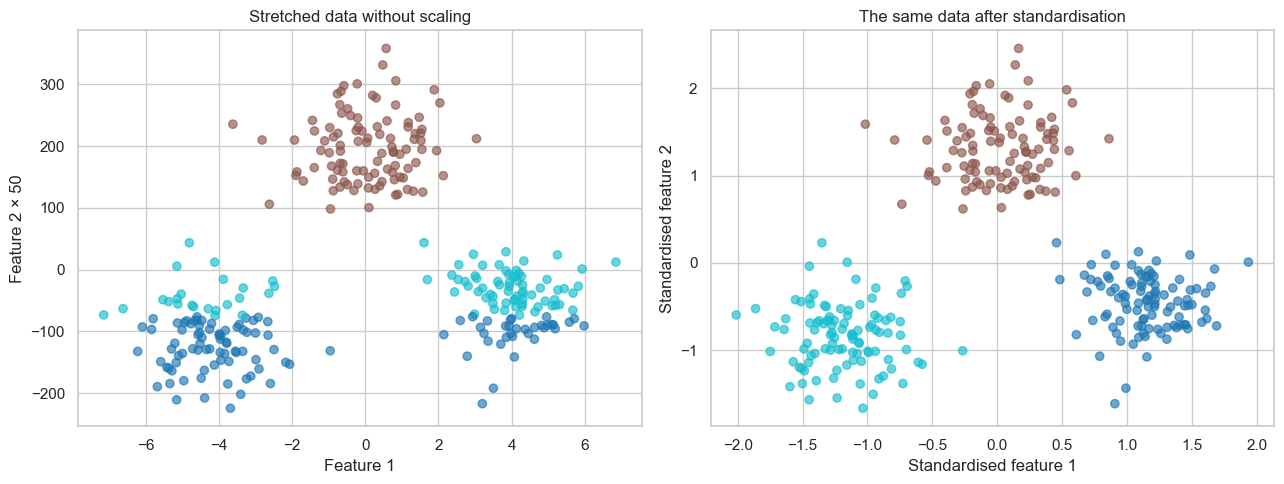

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    X_stretched[:, 0],
    X_stretched[:, 1],
    c=labels_stretched_raw,
    alpha=0.65,
    cmap="tab10",
)
axes[0].set_title("Stretched data without scaling")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2 × 50")

axes[1].scatter(
    X_stretched_scaled[:, 0],
    X_stretched_scaled[:, 1],
    c=labels_stretched_scaled,
    alpha=0.65,
    cmap="tab10",
)
axes[1].set_title("The same data after standardisation")
axes[1].set_xlabel("Standardised feature 1")
axes[1].set_ylabel("Standardised feature 2")

plt.tight_layout()
plt.show()

### Activity 3 - Explain the mechanism

Complete the argument:

> Multiplying one feature by 50 changed the clustering because Euclidean distance ...
>
> Standardisation changed the result because it ...
>
> This experiment does not prove that every feature should always receive equal weight because ...

## 5. Real-world clustering: Titanic passengers

We now cluster passengers using a small set of interpretable variables.

### Important modelling decision

`Survived` will **not** be used to create the clusters. We will keep it only as an external variable for later interpretation.

Before running the next cells, answer:

1. Why would including `Survived` partly build the later conclusion into the clusters?
2. Are we trying to predict survival here?
3. What should one row and one distance represent?

**Do not use a variable to create clusters if you later want to use that same variable to evaluate or interpret differences between the clusters.**

**Dataset source:** Titanic passenger data used in the original course materials.

The cell first looks for `titanic.csv` locally and otherwise loads the course copy from GitHub.

In [21]:
TITANIC_URL = (
    "https://raw.githubusercontent.com/jplatos/VSB-FEI-Fundamentals-of-Machine-Learning/refs/heads/master/Datasets/titanic.csv"
)
LOCAL_TITANIC_PATH = Path("titanic.csv")

titanic_source = (
    LOCAL_TITANIC_PATH
    if LOCAL_TITANIC_PATH.exists()
    else TITANIC_URL
)

titanic_full = pd.read_csv(titanic_source)

print(f"Source: {titanic_source}")
print(
    f"Shape: {titanic_full.shape[0]} rows × "
    f"{titanic_full.shape[1]} columns"
)
titanic_full.head()

Source: https://raw.githubusercontent.com/jplatos/VSB-FEI-Fundamentals-of-Machine-Learning/refs/heads/master/Datasets/titanic.csv
Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


### Build a transparent analytical representation

We will use:

- numerical features: `Age`, `Fare`, `SibSp`, `Parch`,
- categorical features: `Sex`, `Embarked`, `Pclass`,
- external interpretation variable: `Survived`.

For this introductory exercise:

- missing numerical values are replaced by the median,
- missing categorical values are replaced by the most frequent category,
- `Fare` is transformed with `log1p` because of its long upper tail,
- numerical features are standardised,
- categorical features are one-hot encoded.

These are defensible starting choices, not universal rules.

In [27]:
feature_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Sex",
    "Embarked",
    "Pclass",
]
external_columns = ["Survived"]

titanic = titanic_full.loc[
    :,
    feature_columns + external_columns,
].copy()

titanic["Age"] = titanic["Age"].fillna(
    titanic["Age"].median()
)
titanic["Fare"] = titanic["Fare"].fillna(
    titanic["Fare"].median()
)
titanic["Embarked"] = titanic["Embarked"].fillna(
    titanic["Embarked"].mode().iloc[0]
)

titanic["Fare_log"] = np.log1p(titanic["Fare"])
titanic["FamilySize"] = (
    titanic["SibSp"] + titanic["Parch"] + 1
)

titanic.head()

,Age,Fare,SibSp,Parch,Sex,Embarked,Pclass,Survived,Fare_log,FamilySize
0,22.000,7.250,1,0,male,S,3,0,2.110,2
1,38.000,71.283,1,0,female,C,1,1,4.281,2
2,26.000,7.925,0,0,female,S,3,1,2.189,1
3,35.000,53.100,1,0,female,S,1,1,3.991,2
4,35.000,8.050,0,0,male,S,3,0,2.203,1


### Predict before preprocessing

1. Which raw numerical feature probably has the largest scale?
2. Why transform `Fare` before standardising it?
3. Why treat `Pclass` as a category in this notebook even though it has an order?
4. What information is lost when we one-hot encode a genuinely ordered variable?

In [29]:
numeric_features = [
    "Age",
    "Fare_log",
    "SibSp",
    "Parch",
]

numeric_scaler = StandardScaler()

X_numeric = pd.DataFrame(
    numeric_scaler.fit_transform(
        titanic[numeric_features]
    ),
    columns=numeric_features,
    index=titanic.index,
)

X_categorical = pd.get_dummies(
    titanic[["Sex", "Embarked", "Pclass"]].astype(str),
    prefix=["Sex", "Embarked", "Pclass"],
    dtype=float,
)

X_titanic = pd.concat(
    [X_numeric, X_categorical],
    axis=1,
)

print(
    f"Prepared matrix: {X_titanic.shape[0]} passengers × "
    f"{X_titanic.shape[1]} features"
)
X_titanic.head()

Prepared matrix: 891 passengers × 12 features


,Age,Fare_log,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,-0.566,-0.880,0.433,-0.474,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000
1,0.664,1.361,0.433,-0.474,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
2,-0.258,-0.799,-0.475,-0.474,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
3,0.433,1.062,0.433,-0.474,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000
4,0.433,-0.784,-0.475,-0.474,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000


### Verification checkpoint

Use the outputs below to check whether:

- numerical columns are centred near zero,
- dummy columns contain only 0 and 1,
- `Survived` is absent from the clustering matrix.

In [30]:
display(
    X_titanic[numeric_features]
    .agg(["mean", "std", "min", "max"])
)

display(
    X_titanic.drop(columns=numeric_features)
    .apply(lambda column: sorted(column.unique()))
)

print(
    "Survived in clustering matrix:",
    "Survived" in X_titanic.columns,
)

,Age,Fare_log,SibSp,Parch
mean,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001
min,-2.224,-3.059,-0.475,-0.474
max,3.892,3.385,6.784,6.974


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Survived in clustering matrix: False


## 6. Evaluate candidate values of k

We will inspect \(k = 2, \ldots, 8\).

Before running the cell, predict:

1. Do you expect one sharp, unambiguous optimum?
2. Would the largest silhouette score automatically guarantee useful passenger profiles?
3. Why should very small clusters be inspected carefully?

In [31]:
titanic_scores = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42,
    )
    labels = model.fit_predict(X_titanic)

    cluster_sizes = pd.Series(labels).value_counts()

    titanic_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X_titanic,
                labels,
            ),
            "smallest_cluster": cluster_sizes.min(),
        }
    )

titanic_scores = pd.DataFrame(titanic_scores)
titanic_scores

,k,inertia,silhouette,smallest_cluster
0,2,"3,780.578",0.297,294
1,3,"2,999.758",0.281,134
2,4,"2,619.147",0.298,44
3,5,"2,381.580",0.251,44
4,6,"2,178.494",0.248,44
5,7,"2,002.595",0.254,12
6,8,"1,873.810",0.262,23


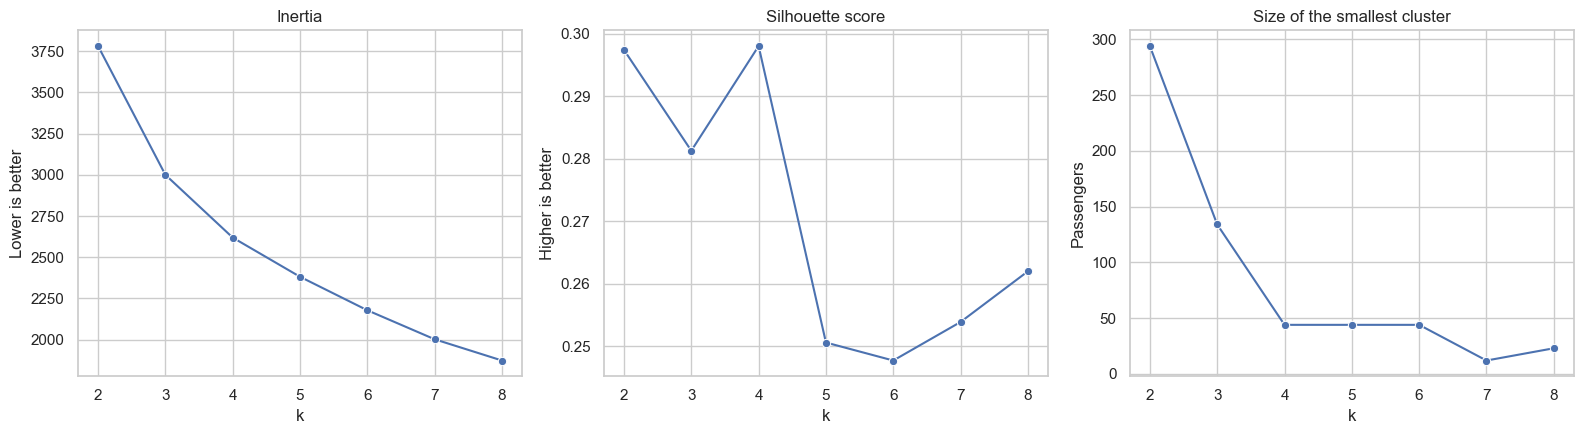

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.lineplot(
    data=titanic_scores,
    x="k",
    y="inertia",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Inertia")
axes[0].set_ylabel("Lower is better")

sns.lineplot(
    data=titanic_scores,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Silhouette score")
axes[1].set_ylabel("Higher is better")

sns.lineplot(
    data=titanic_scores,
    x="k",
    y="smallest_cluster",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Size of the smallest cluster")
axes[2].set_ylabel("Passengers")

plt.tight_layout()
plt.show()

### Activity 4 — Select a defensible candidate

Write a short argument for one candidate \(k\). Your argument must mention:

- the elbow or rate of inertia reduction,
- the silhouette score,
- the size of the smallest cluster,
- the need to inspect whether the resulting profiles are understandable.

The notebook uses `SELECTED_K = 3` as a common classroom starting point. You may change it after examining the evidence.

In [33]:
SELECTED_K = 3

titanic_model = KMeans(
    n_clusters=SELECTED_K,
    n_init=20,
    random_state=42,
)
titanic_labels = titanic_model.fit_predict(X_titanic)

titanic_result = titanic.copy()
titanic_result["cluster"] = titanic_labels

titanic_result["cluster"].value_counts().sort_index()

cluster
0    267
1    490
2    134
Name: count, dtype: int64

## 7. Interpret clusters in the original units

Centroids live in the prepared feature space. Human interpretation is usually easier in the original variables.

The profile below reports:

- cluster size,
- median age and fare,
- mean family size,
- proportion of women,
- proportion of first-class passengers,
- survival rate as an **external descriptive variable**.

A high survival rate does not mean that the cluster caused survival.

In [34]:
cluster_profile = (
    titanic_result
    .groupby("cluster")
    .agg(
        passengers=("cluster", "size"),
        median_age=("Age", "median"),
        median_fare=("Fare", "median"),
        mean_family_size=("FamilySize", "mean"),
        female_share=(
            "Sex",
            lambda values: (values == "female").mean(),
        ),
        first_class_share=(
            "Pclass",
            lambda values: (values == 1).mean(),
        ),
        survival_rate=("Survived", "mean"),
    )
)

cluster_profile["share_of_dataset"] = (
    cluster_profile["passengers"] / len(titanic_result)
)

cluster_profile = cluster_profile[
    [
        "passengers",
        "share_of_dataset",
        "median_age",
        "median_fare",
        "mean_family_size",
        "female_share",
        "first_class_share",
        "survival_rate",
    ]
]

cluster_profile

,passengers,share_of_dataset,median_age,median_fare,mean_family_size,female_share,first_class_share,survival_rate
cluster,,,,,,,,
0,267,0.300,36.000,51.862,1.610,0.419,0.719,0.581
1,490,0.550,28.000,8.050,1.245,0.253,0.012,0.251
2,134,0.150,16.000,29.062,4.903,0.582,0.134,0.478


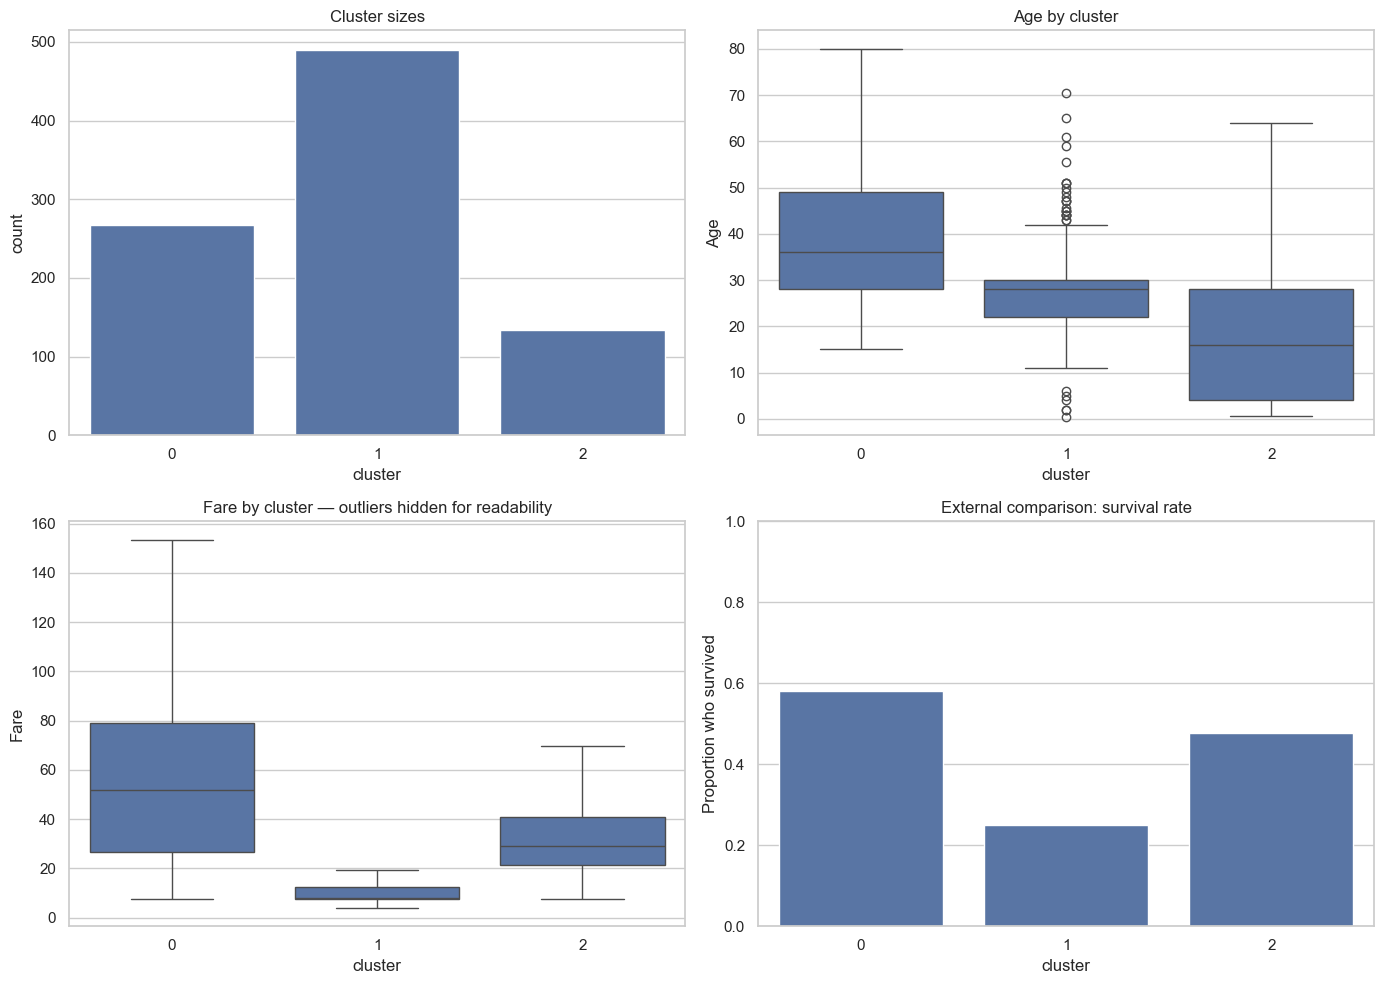

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=titanic_result,
    x="cluster",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Cluster sizes")

sns.boxplot(
    data=titanic_result,
    x="cluster",
    y="Age",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Age by cluster")

sns.boxplot(
    data=titanic_result,
    x="cluster",
    y="Fare",
    showfliers=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Fare by cluster — outliers hidden for readability")

survival_by_cluster = (
    titanic_result
    .groupby("cluster")["Survived"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=survival_by_cluster,
    x="cluster",
    y="Survived",
    ax=axes[1, 1],
)
axes[1, 1].set_title("External comparison: survival rate")
axes[1, 1].set_ylabel("Proportion who survived")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Activity 5 — Name clusters cautiously

For each cluster, write **two or three sentences**.

Use this structure:

> Cluster ... contains ... passengers. Compared with the full dataset, it has a higher/lower ... and a typical ... of .... A cautious descriptive name could be “...”, although the cluster also contains exceptions.

Rules:

- support every description with at least two values from the profile,
- do not use the arbitrary number as the meaning,
- avoid causal statements,
- mention at least one within-cluster variation or limitation.

## 8. Is the solution stable?

A result that changes strongly with random initialisation should be interpreted cautiously.

We compare ten runs with the same \(k\). The first run is the reference. ARI compares each later partition with it.

In [36]:
stability_labels = []

for seed in range(10):
    model = KMeans(
        n_clusters=SELECTED_K,
        n_init=1,
        random_state=seed,
    )
    stability_labels.append(
        model.fit_predict(X_titanic)
    )

reference_labels = stability_labels[0]

stability = pd.DataFrame(
    {
        "seed": range(10),
        "ARI_vs_seed_0": [
            adjusted_rand_score(
                reference_labels,
                labels,
            )
            for labels in stability_labels
        ],
    }
)

stability

,seed,ARI_vs_seed_0
0,0,1.000
1,1,0.994
2,2,0.938
3,3,0.935
4,4,0.286
5,5,0.998
6,6,0.994
7,7,0.998
8,8,0.935
9,9,0.938


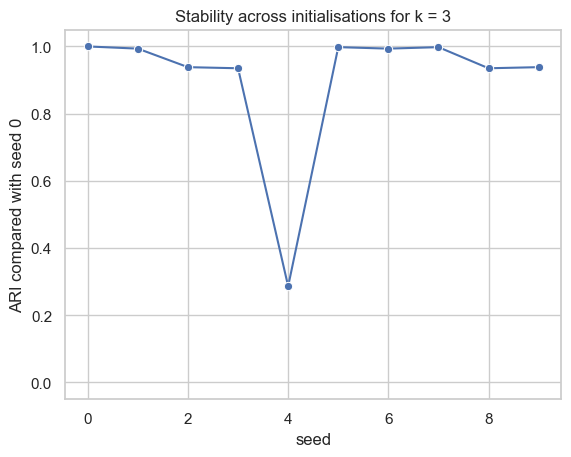

In [37]:
sns.lineplot(
    data=stability,
    x="seed",
    y="ARI_vs_seed_0",
    marker="o",
)
plt.ylim(-0.05, 1.05)
plt.title(
    f"Stability across initialisations for k = {SELECTED_K}"
)
plt.ylabel("ARI compared with seed 0")
plt.show()

### Activity 6 — Interpret stability

1. Is the solution identical across all initialisations?
2. Would increasing `n_init` make the final run more reliable? Why?
3. Does high stability prove that the clusters are useful?
4. Does lower stability automatically mean that the data contain no structure?

## 9. Homework - Country data

This final task prepares you for the first part of the semester project.

Each row represents a country and the variables describe health, demographic, and economic indicators.

Your goal is not to produce the most impressive plot. Your goal is to construct and defend a complete analytical chain:

> **representation → scaling → choice of k → profiles → interpretation → limitation**

In [ ]:
COUNTRY_URL = (
    "https://raw.githubusercontent.com/rasvob/"
    "VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/"
    "master/datasets/country-data.csv"
)
LOCAL_COUNTRY_PATH = Path("country-data.csv")

country_source = (
    LOCAL_COUNTRY_PATH
    if LOCAL_COUNTRY_PATH.exists()
    else COUNTRY_URL
)

countries = pd.read_csv(country_source)

print(f"Source: {country_source}")
print(
    f"Shape: {countries.shape[0]} rows × "
    f"{countries.shape[1]} columns"
)
countries.head()

### Final task

Use the prepared framework below.

1. Inspect the variables and decide whether all numerical columns should enter the clustering.
2. Standardise the selected variables.
3. Evaluate \(k = 2, \ldots, 7\).
4. Choose `COUNTRY_K`.
5. Build a cluster profile in original units.
6. Describe every cluster.
7. Name one country that seems unusual within its cluster.
8. State one limitation of interpreting countries only from these indicators.

The code is intentionally almost complete. Your main work is the **decision and interpretation**, not writing a long program.

In [ ]:
country_numeric = countries.select_dtypes(include="number").copy()

country_scaler = StandardScaler()
X_country = country_scaler.fit_transform(country_numeric)

country_scores = []

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42,
    )
    labels = model.fit_predict(X_country)

    country_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X_country,
                labels,
            ),
            "smallest_cluster": pd.Series(
                labels
            ).value_counts().min(),
        }
    )

country_scores = pd.DataFrame(country_scores)
country_scores

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=country_scores,
    x="k",
    y="inertia",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Country data: inertia")

sns.lineplot(
    data=country_scores,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Country data: silhouette")

plt.tight_layout()
plt.show()

In [ ]:
COUNTRY_K = 3  # Change only after examining the evidence.

country_model = KMeans(
    n_clusters=COUNTRY_K,
    n_init=20,
    random_state=42,
)
country_labels = country_model.fit_predict(X_country)

country_result = countries.copy()
country_result["cluster"] = country_labels

country_profile = (
    country_result
    .groupby("cluster")
    .agg(
        countries=("country", "size"),
        child_mortality=("child_mort", "median"),
        exports=("exports", "median"),
        health=("health", "median"),
        income=("income", "median"),
        inflation=("inflation", "median"),
        life_expectancy=("life_expec", "median"),
        fertility=("total_fer", "median"),
        gdpp=("gdpp", "median"),
    )
)

country_profile

In [ ]:
# Inspect countries within one cluster at a time.
CLUSTER_TO_INSPECT = 0

country_result.loc[
    country_result["cluster"] == CLUSTER_TO_INSPECT
].sort_values("gdpp").head(20)

### Submission checkpoint

Your final Markdown response should contain:

1. the selected \(k\) and the evidence for it,
2. a concise description of every cluster,
3. at least two numerical values supporting each description,
4. one unusual country and the reason it deserves inspection,
5. one limitation of the representation,
6. one change you would test next.

### Project bridge

For your own semester dataset, write down:

- what one row represents,
- which columns should define similarity,
- which columns should be excluded from clustering,
- which features require scaling or transformation,
- how you will evaluate candidate values of \(k\),
- how you will interpret and verify the resulting clusters.

## Summary

The central lessons of this exercise are:

- K-means operates on a chosen numerical representation, not directly on real-world meaning.
- Scaling can change the geometry and therefore the clusters.
- Inertia always improves as \(k\) grows; the silhouette score is useful but not decisive.
- Cluster numbers are arbitrary identifiers.
- A cluster must be interpreted in the original variables and with evidence.
- External variables may help describe clusters, but they should not silently define them.
- Stability is evidence about reproducibility, not proof of usefulness.
- AI is most valuable here when it questions an interpretation that you wrote first.